<a href="https://colab.research.google.com/github/KurniaYufi/nlp-sentiment-analisis/blob/main/Week1_Bibit_Scrapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install google_play_scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00


In [2]:
from google_play_scraper import app
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns

**Scrapping Data**

In [5]:
from google_play_scraper import app, Sort, reviews_all

bibit_reviews = reviews_all(
    'com.bibit.bibitid', # Google Play id for Bibit
    sleep_milliseconds=0,
    lang='id', # review language
    sort=Sort.NEWEST,
)

In [15]:
df_result = pd.DataFrame(np.array(bibit_reviews),columns=['content'])
df_result = df_result.join(pd.DataFrame(df_result.pop('content').tolist()))
df_result.to_csv(r'df_review_bibit.csv', index=False)

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
df_result

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,7a1e7ff5-5f01-4a1a-a243-94297453c196,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baik,5,0,3.106.1,2026-03-30 05:08:53,Terima kasih Kak Imam telah memilih Bibit seba...,2026-03-30 06:09:03,3.106.1
1,7c05c1c8-8548-4ce3-99ff-55fa773e237c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,okelah buat nabung,5,0,3.106.2,2026-03-30 01:40:09,Terima kasih telah memilih Bibit sebagai platf...,2026-03-30 01:54:07,3.106.2
2,5fe28643-10fc-4082-8cb0-c6d24867137e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Apk rekomendasi untuk pemula yang ingin tau te...,5,0,3.106.2,2026-03-30 01:38:55,Terima kasih telah memilih Bibit sebagai platf...,2026-03-30 01:54:03,3.106.2
3,994552cc-8b6e-4156-bdbe-e1899a611f8f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,3.106.1,2026-03-29 17:29:32,Terima kasih telah memilih Bibit sebagai platf...,2026-03-30 01:54:00,3.106.1
4,eabc7e21-249d-424c-b6de-d61308016aba,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,3.106.1,2026-03-29 14:31:37,Terima kasih atas kepercayaan & kesetiaan kaka...,2026-03-29 16:22:37,3.106.1
...,...,...,...,...,...,...,...,...,...,...,...
49053,0dc6339f-abba-43d9-afe5-746de3ddc4db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"bgus nih aplikasi ,jdi lebih mudah pilih sama ...",5,2,None,2019-01-11 10:00:42,None,NaT,None
49054,3e96d1f4-a4ba-4d76-83b9-bf153bf07189,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Daripada taro duit di bank dimana bunga rendah...,5,4,1.1.0,2019-01-11 08:58:00,None,NaT,1.1.0
49055,fbcc0662-445c-4054-b446-77730664dfc9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Design nya sangat bagus, dan membuat investasi...",5,4,1.1.0,2019-01-11 08:53:13,None,NaT,1.1.0
49056,8db8cabb-5722-4300-9954-2d62a2437a54,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Mantap bibit,5,0,1.1.0,2019-01-11 02:43:56,None,NaT,1.1.0


In [8]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49058 entries, 0 to 49057
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              49058 non-null  object        
 1   userName              49058 non-null  object        
 2   userImage             49058 non-null  object        
 3   content               49058 non-null  object        
 4   score                 49058 non-null  int64         
 5   thumbsUpCount         49058 non-null  int64         
 6   reviewCreatedVersion  42081 non-null  object        
 7   at                    49058 non-null  datetime64[ns]
 8   replyContent          10546 non-null  object        
 9   repliedAt             10546 non-null  datetime64[ns]
 10  appVersion            42081 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 4.1+ MB


In [9]:
# Selected Columns
df_analysis = df_result.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]
df_analysis

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,baik,5,0,3.106.1,2026-03-30 05:08:53,Terima kasih Kak Imam telah memilih Bibit seba...,2026-03-30 06:09:03
1,okelah buat nabung,5,0,3.106.2,2026-03-30 01:40:09,Terima kasih telah memilih Bibit sebagai platf...,2026-03-30 01:54:07
2,Apk rekomendasi untuk pemula yang ingin tau te...,5,0,3.106.2,2026-03-30 01:38:55,Terima kasih telah memilih Bibit sebagai platf...,2026-03-30 01:54:03
3,good,5,0,3.106.1,2026-03-29 17:29:32,Terima kasih telah memilih Bibit sebagai platf...,2026-03-30 01:54:00
4,good,5,0,3.106.1,2026-03-29 14:31:37,Terima kasih atas kepercayaan & kesetiaan kaka...,2026-03-29 16:22:37
...,...,...,...,...,...,...,...
49053,"bgus nih aplikasi ,jdi lebih mudah pilih sama ...",5,2,None,2019-01-11 10:00:42,None,NaT
49054,Daripada taro duit di bank dimana bunga rendah...,5,4,1.1.0,2019-01-11 08:58:00,None,NaT
49055,"Design nya sangat bagus, dan membuat investasi...",5,4,1.1.0,2019-01-11 08:53:13,None,NaT
49056,Mantap bibit,5,0,1.1.0,2019-01-11 02:43:56,None,NaT


In [10]:
#Check number of reviews scores
df_result['score'].value_counts()

,count
score,
5,34076
1,5808
4,5213
3,2515
2,1446


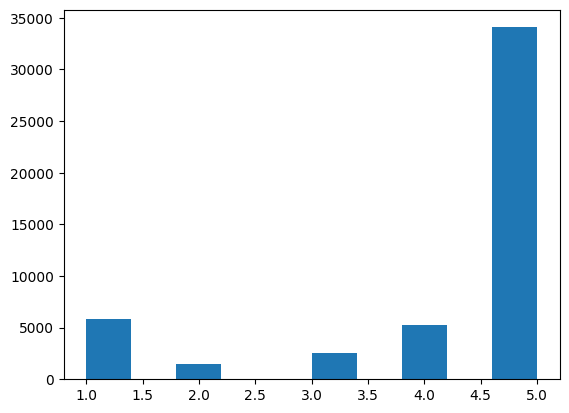

In [11]:
plt.hist(df_result['score'])
plt.show()